In [2]:
import matplotlib.pyplot as plt
import numpy as np

from src.model import _DiffusionBase

/home/justin/msc_ai/individual-project/diffusion-irregular-ehr/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
num_steps = 100
beta_start = 1e-4
default_beta_end = 0.5

## Schedule Comparison

In [ ]:
betas_linear = np.linspace(beta_start, default_beta_end, num_steps)
betas_quadratic = np.linspace(beta_start**0.5, default_beta_end**0.5, num_steps) ** 2
betas_cosine = _DiffusionBase.cosine_beta_schedule(num_steps)

betas_list = [
    # betas_linear,
    betas_quadratic,
    # betas_cosine,
]
alphas_list = [1 - betas for betas in betas_list]
alpha_bar_list = [np.cumprod(alphas) for alphas in alphas_list]

print([alpha_bar[-1] for alpha_bar in alpha_bar_list])
print([np.sqrt(alpha_bar[-1]) for alpha_bar in alpha_bar_list])

[np.float64(1.3051071228707825e-09)]
[np.float64(3.6126266384319076e-05)]


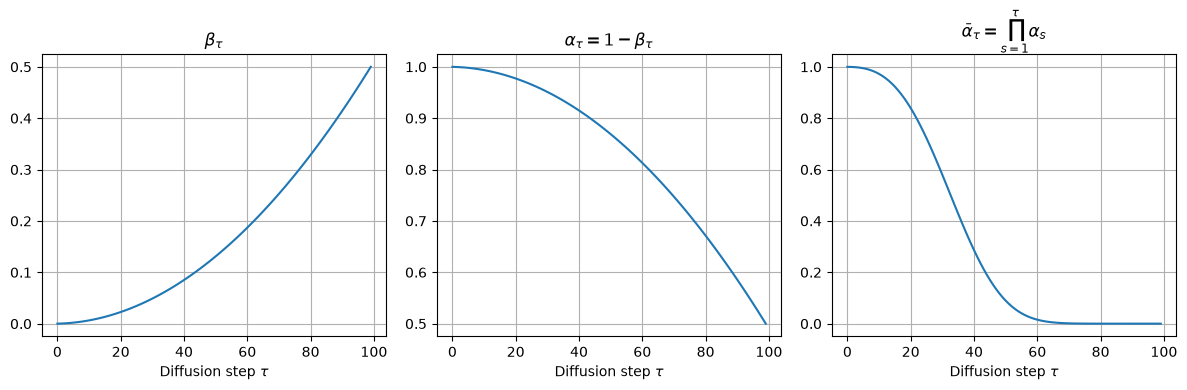

In [57]:
fig, axs = plt.subplots(1, 3, figsize=(12, 4))
ax0, ax1, ax2 = axs

schedules = [
    # "linear",
    "quadratic",
    # "cosine",
]

ax0.set_title(r"$\beta_\tau$")
for betas in betas_list:
    ax0.plot(betas)
# ax0.semilogy()

ax1.set_title(r"$\alpha_\tau = 1 - \beta_\tau$")
for alphas, schedule in zip(alphas_list, schedules, strict=True):
    ax1.plot(alphas, label=schedule)
# ax1.semilogy()
# ax1.legend()

ax2.set_title(r"$\bar{\alpha}_\tau = \prod_{s=1}^\tau \alpha_s$")
for alpha_bar in alpha_bar_list:
    ax2.plot(alpha_bar)

for ax in axs:
    ax.set_xlabel(r"Diffusion step $\tau$")
    ax.grid()

plt.tight_layout()
plt.show()

## `beta_end` Comparison

Final alpha_bar and sqrt(alpha_bar) values:

num_steps=100:
['beta_end=0.5: 1.305e-09, 3.613e-05', 'beta_end=0.2: 0.0006677, 0.02584', 'beta_end=0.15: 0.004475, 0.06689', 'beta_end=0.1: 0.02821, 0.168']

num_steps=150:
['beta_end=0.5: 5.073e-14, 2.252e-07', 'beta_end=0.2: 1.76e-05, 0.004195', 'beta_end=0.15: 0.0003036, 0.01742', 'beta_end=0.1: 0.004781, 0.06914']

num_steps=200:
['beta_end=0.5: 1.971e-18, 1.404e-09', 'beta_end=0.2: 4.637e-07, 0.000681', 'beta_end=0.15: 2.059e-05, 0.004538', 'beta_end=0.1: 0.00081, 0.02846']


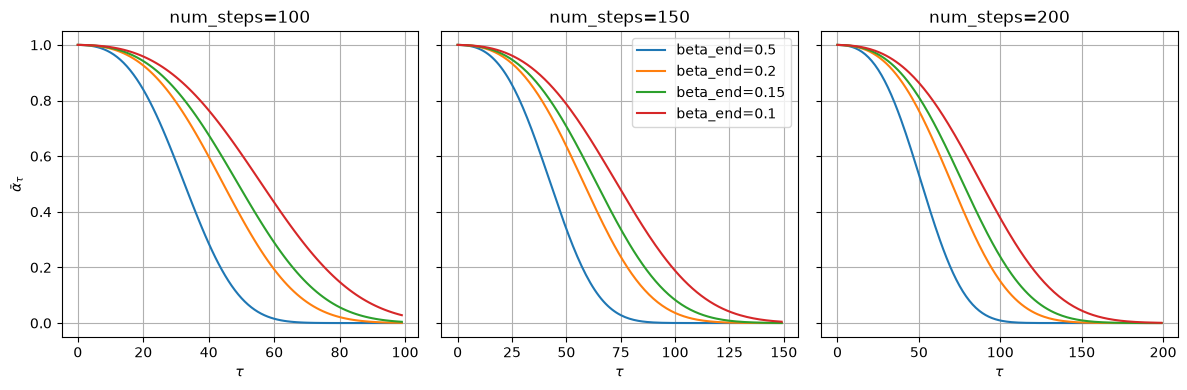

In [13]:
num_steps_list = [100, 150, 200]
beta_ends = [0.5, 0.2, 0.15, 0.1]

fig, axs = plt.subplots(
    1, len(num_steps_list), figsize=(len(num_steps_list) * 4, 4), sharey=True
)

print("Final alpha_bar and sqrt(alpha_bar) values:")

for i, num_steps in enumerate(num_steps_list):
    print(f"\nnum_steps={num_steps}:")
    betas_list = [np.linspace(beta_start**0.5, end**0.5, num_steps) ** 2 for end in beta_ends]
    alphas_list = [1 - betas for betas in betas_list]
    alpha_bar_list = [np.cumprod(alphas) for alphas in alphas_list]

    print(
        [
            f"beta_end={beta_end}: {alpha_bar[-1]:.4g}, {np.sqrt(alpha_bar[-1]):.4g}"
            for alpha_bar, beta_end in zip(alpha_bar_list, beta_ends, strict=True)
        ]
    )

    for alpha_bar, end in zip(alpha_bar_list, beta_ends, strict=True):
        axs[i].plot(alpha_bar, label=f"beta_end={end}")
    axs[i].set_title(f"num_steps={num_steps}")
    axs[i].set_xlabel(r"$\tau$")
    if i == 0:
        axs[i].set_ylabel(r"$\bar{\alpha}_\tau$")
    axs[i].grid()

    if i == len(num_steps_list) // 2:
        axs[i].legend()

plt.tight_layout()
plt.show()

Final alpha_bar and sqrt(alpha_bar) values:

num_steps=250:
['beta_end=0.08: 0.0008279, 0.02877', 'beta_end=0.07: 0.002018, 0.04493', 'beta_end=0.05: 0.01184, 0.1088']

num_steps=300:
['beta_end=0.08: 0.0002008, 0.01417', 'beta_end=0.07: 0.0005848, 0.02418', 'beta_end=0.05: 0.004883, 0.06988']

num_steps=400:
['beta_end=0.08: 1.181e-05, 0.003437', 'beta_end=0.07: 4.909e-05, 0.007007', 'beta_end=0.05: 0.0008306, 0.02882']


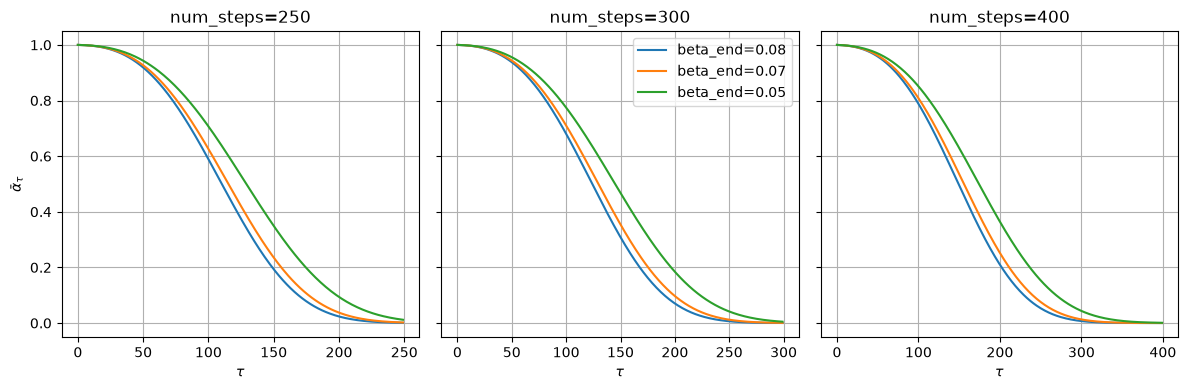

In [14]:
num_steps_list = [250, 300, 400]
beta_ends = [0.08, 0.07, 0.05]

fig, axs = plt.subplots(
    1, len(num_steps_list), figsize=(len(num_steps_list) * 4, 4), sharey=True
)

print("Final alpha_bar and sqrt(alpha_bar) values:")

for i, num_steps in enumerate(num_steps_list):
    print(f"\nnum_steps={num_steps}:")
    betas_list = [np.linspace(beta_start**0.5, end**0.5, num_steps) ** 2 for end in beta_ends]
    alphas_list = [1 - betas for betas in betas_list]
    alpha_bar_list = [np.cumprod(alphas) for alphas in alphas_list]

    print(
        [
            f"beta_end={beta_end}: {alpha_bar[-1]:.4g}, {np.sqrt(alpha_bar[-1]):.4g}"
            for alpha_bar, beta_end in zip(alpha_bar_list, beta_ends, strict=True)
        ]
    )

    for alpha_bar, end in zip(alpha_bar_list, beta_ends, strict=True):
        axs[i].plot(alpha_bar, label=f"beta_end={end}")
    axs[i].set_title(f"num_steps={num_steps}")
    axs[i].set_xlabel(r"$\tau$")
    if i == 0:
        axs[i].set_ylabel(r"$\bar{\alpha}_\tau$")
    axs[i].grid()

    if i == len(num_steps_list) // 2:
        axs[i].legend()

plt.tight_layout()
plt.show()

In [4]:
def geomean_compounding(alphas: np.ndarray, window_frac: float = 0.2) -> float:
    """Geometric mean of the per-step 1/sqrt(alpha) multiplier over the last
    window_frac fraction of the schedule.

    This is the typical single-step amplification risk in that region,
    independent of how many steps are in the window (unlike a raw product,
    which grows with window length).
    """
    n = max(1, round(len(alphas) * window_frac))

    # 1/sqrt(alphas) is used as it's the outer multiplicative factor wrapping the
    # entire reverse-step formula:
    #
    # mu = (1.0 / alpha.sqrt()) * (y - (beta / (1.0 - alpha_bar).sqrt()) * eps_pred)

    per_step = 1.0 / np.sqrt(alphas[-n:])
    return per_step.prod() ** (1.0 / n)

In [5]:
# Default L and beta_end
betas = np.linspace(beta_start**0.5, default_beta_end**0.5, num_steps) ** 2
alphas = 1 - betas
geomean_compounding(alphas)

np.float64(1.3061481391105472)

In [6]:
# L=200 and beta_end=0.1
L = 200
beta_end = 0.1
betas = np.linspace(beta_start**0.5, beta_end**0.5, L) ** 2
alphas = 1 - betas
geomean_compounding(alphas)

np.float64(1.043874398201803)